In [1]:
# This cell imports the libraries we need for working with NinaPro data.
# Think of libraries like "tools" we add to Python to do specific tasks.

# scipy.io: For loading .mat files (MATLAB format)
import scipy.io as sio

# numpy: For numerical operations (like arrays and math)
import numpy as np

# matplotlib.pyplot: For plotting graphs (to visualize EMG signals)
import matplotlib.pyplot as plt

In [2]:
# This cell loads the S1_A1_E1.mat file from your ninaprodb folder.

# Path to the file (adjust if your folder is named differently)
file_path = 'ninaprodb/s1/S1_A1_E1.mat'

# Load the .mat file into a variable called 'data'
data = sio.loadmat(file_path)

# Print all the "keys" (names of the data inside the file)
print("Keys in the .mat file:", data.keys())

Keys in the .mat file: dict_keys(['__header__', '__version__', '__globals__', 'emg', 'stimulus', 'glove', 'subject', 'exercise', 'repetition', 'restimulus', 'rerepetition'])


In [4]:
# Extract data with correct assumptions
emg = data['emg']  # Shape: (101014, 10) = (samples, electrodes)
restimulus = data['restimulus'].flatten()  # Shape: (101014,)
fs = 100  # Preprocessed to 100 Hz (from the paper)

print("EMG shape:", emg.shape)  # (101014, 10)
print("Restimulus shape:", restimulus.shape)
print("Sampling frequency:", fs, "Hz")
print("Unique gestures:", np.unique(restimulus))  # Should show 1-12

EMG shape: (101014, 10)
Restimulus shape: (101014,)
Sampling frequency: 100 Hz
Unique gestures: [ 0  1  2  3  4  5  6  7  8  9 10 11 12]


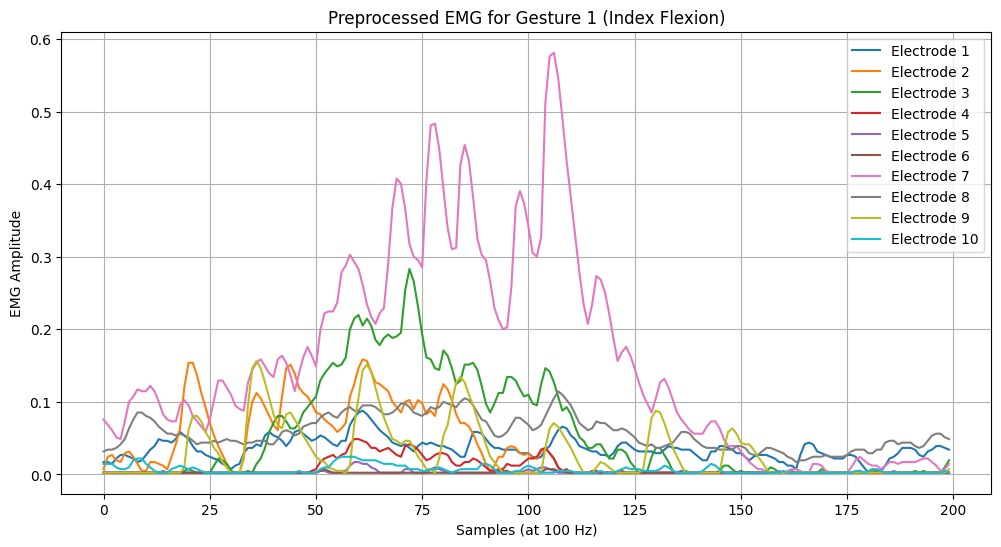

In [6]:
# Plot EMG for gesture 1 (Index Flexion)
gesture_id = 1
gesture_indices = np.where(restimulus == gesture_id)[0]

# Take first 200 samples (2 seconds at 100 Hz)
start_idx = gesture_indices[0]
end_idx = start_idx + 200

plt.figure(figsize=(12, 6))
for i in range(10):  # 10 electrodes
    plt.plot(emg[start_idx:end_idx, i], label=f'Electrode {i+1}')
plt.xlabel('Samples (at 100 Hz)')
plt.ylabel('EMG Amplitude')
plt.title(f'Preprocessed EMG for Gesture {gesture_id} (Index Flexion)')
plt.legend()
plt.grid()
plt.show()

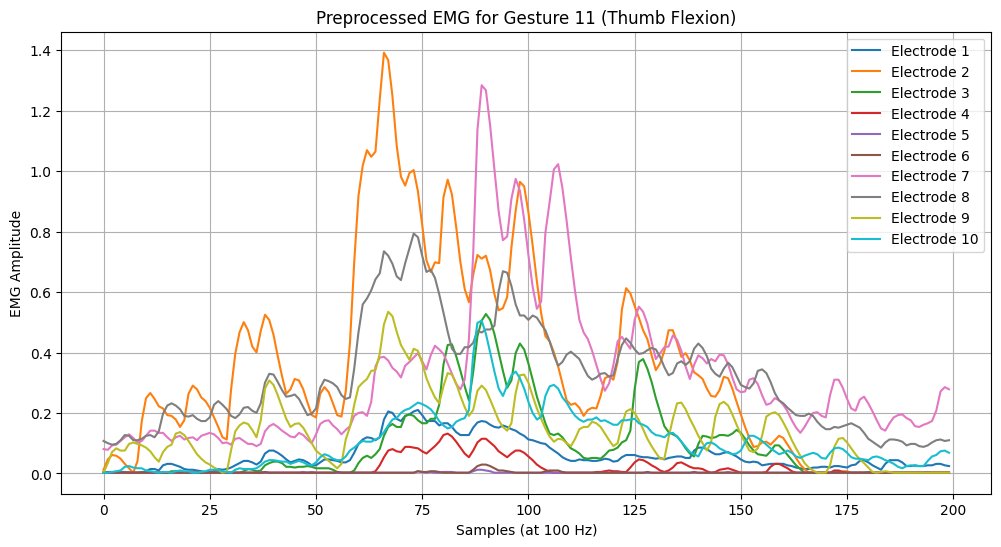

In [7]:
# Plot EMG for gesture 11 (Thumb Flexion)
gesture_id = 11
gesture_indices = np.where(restimulus == gesture_id)[0]

start_idx = gesture_indices[0]
end_idx = start_idx + 200

plt.figure(figsize=(12, 6))
for i in range(10):
    plt.plot(emg[start_idx:end_idx, i], label=f'Electrode {i+1}')
plt.xlabel('Samples (at 100 Hz)')
plt.ylabel('EMG Amplitude')
plt.title(f'Preprocessed EMG for Gesture {gesture_id} (Thumb Flexion)')
plt.legend()
plt.grid()
plt.show()